# Fair-Seldonian — Quickstart

*Fairness-constrained machine learning with high-confidence guarantees.*

This notebook walks through the [`fair-seldonian`](https://github.com/parulgupta1004/fair-seldonian) package end to end:

1. Generate synthetic data with a controllable fairness gap
2. Train a model with the **Quasi-Seldonian Algorithm (QSA)**
3. Read the safety guarantee (`passed` + the high-confidence upper bound)
4. See the difference between a *fair* dataset (model returned) and an *unfair* one (**No Solution Found**)
5. Customise the constraint, confidence level $\delta$, and inequality
6. Compare the five algorithm variants

The Seldonian guarantee: given a behavioural constraint and a confidence level $\delta$, QSA either returns a model that satisfies the constraint with probability $\ge 1 - \delta$, or it returns **No Solution Found** — it never returns an unsafe model.

## 0. Install

Uncomment if the package isn't already in your environment.

In [1]:
# %pip install fair-seldonian

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

import fair_seldonian
from fair_seldonian.algorithms import QSA
from fair_seldonian.config import SeldonianConfig
from fair_seldonian.constraints.inequalities import Inequality
from fair_seldonian.data import data_split, get_data
from fair_seldonian.models import eval_ghat, predict, simple_logistic

warnings.filterwarnings("ignore")  # keep the demo output tidy

print("fair-seldonian version:", fair_seldonian.__version__)

/Users/parulgupta/fair-seldonian/.venv/lib/python3.13/site-packages/joblib/_multiprocessing_helpers.py:44: UserWarning: [Errno 1] Operation not permitted.  joblib will operate in serial mode
  warnings.warn("%s.  joblib will operate in serial mode" % (e,))


fair-seldonian version: 2.1.1


## 1. The data

`get_data` builds a synthetic binary-classification dataset where each row carries a **sensitive attribute** `T` $\in \{0, 1\}$ (e.g. a protected group).

| argument | meaning |
|---|---|
| `N` | number of samples |
| `features` | number of feature columns |
| `t_ratio` | fraction of rows in group `T=1` |
| `tp0_ratio` | base positive-label rate for group `T=0` |
| `tp1_ratio` | base positive-label rate for group `T=1` |
| `random_seed` | reproducibility |

The gap between `tp0_ratio` and `tp1_ratio` controls how *unfair* the underlying data is. `data_split` then returns train/test arrays as `(X_test, Y_test, T_test, X_train, Y_train, T_train)`.

In [3]:
data = get_data(
    N=10000, features=5, t_ratio=0.4, tp0_ratio=0.4, tp1_ratio=0.6, random_seed=42
)
X_te, Y_te, T_te, X_tr, Y_tr, T_tr = data_split(
    frac=0.5, all_data=data, random_state=1, m_test=0.2
)

print("train:", X_tr.shape, " test:", X_te.shape)
print("group balance (train):", {g: int((T_tr == g).sum()) for g in (0, 1)})

train: (4000, 5)  test: (2000, 5)
group balance (train): {0: 2366, 1: 1634}


## 2. Train with QSA

```python
QSA(X, Y, T, seldonian_type, init_sol, init_sol1, config=DEFAULT_CONFIG)
```

Internally QSA splits the training data into a **candidate** set (used to find a solution) and a **safety** set (used to certify it). It returns `[theta, theta1, passed]`:

- `theta`, `theta1` — the logistic-regression parameters (weights + bias)
- `passed` — `True` only if the candidate model passed the high-confidence safety test

Passing `init_sol=None` lets QSA warm-start from a plain logistic-regression fit. `"opt"` selects the variant with all confidence-bound optimisations enabled (see §6).

In [4]:
theta, theta1, passed = QSA(X_tr, Y_tr, T_tr, "opt", None, None)

if passed:
    ub = float(eval_ghat(theta, theta1, X_te, Y_te, T_te, "opt"))
    print("Safety test PASSED \u2713")
    print(f"High-confidence upper bound on the constraint (test set): {ub:.4f}")
    print("A value \u2264 0 means the fairness constraint is satisfied.")
else:
    print(
        "No Solution Found \u2014 QSA refused to return a model it could not certify."
    )

Safety test PASSED ✓
High-confidence upper bound on the constraint (test set): 0.0198
A value ≤ 0 means the fairness constraint is satisfied.


## 3. What is the constraint?

Constraints are written in **reverse-Polish (postfix) notation** over per-group rates: `TP(g)`, `FP(g)`, `TN(g)`, `FN(g)`.

The default constraint is:

```
TP(1) TP(0) - abs 0.25 TP(1) * -
```

which decodes to

$$ g = \bigl|\, \mathrm{TP}(1) - \mathrm{TP}(0) \,\bigr| \; - \; 0.25 \cdot \mathrm{TP}(1) $$

The Seldonian guarantee enforces $g \le 0$, i.e. the **true-positive-rate gap between the two groups must stay within 25 % of group 1's true-positive rate** (a form of equal-opportunity fairness). QSA certifies an *upper confidence bound* on $g$ rather than its point estimate — that is what makes the guarantee high-confidence.

In [5]:
def tp_rates(theta, theta1, X, Y, T):
    """Empirical true-positive rate per group (for interpretation only)."""
    p = predict(theta, theta1, X).detach().numpy()
    yhat = (p >= 0.5).astype(int)
    rates = {}
    for g in (0, 1):
        mask = (T == g) & (Y == 1)
        rates[g] = float(yhat[mask].mean()) if mask.sum() else float("nan")
    return rates

## 4. Fair vs. unfair data

The same algorithm behaves very differently depending on whether the constraint is *achievable*. We use the t-test inequality here, which gives tighter bounds than Hoeffding when the sample is reasonably large.

In [6]:
def run_scenario(name, tp0, tp1, config):
    data = get_data(
        N=20000,
        features=5,
        t_ratio=0.5,
        tp0_ratio=tp0,
        tp1_ratio=tp1,
        random_seed=7,
    )
    X_te, Y_te, T_te, X_tr, Y_tr, T_tr = data_split(
        frac=1.0, all_data=data, random_state=1, m_test=0.3
    )
    theta, theta1, passed = QSA(X_tr, Y_tr, T_tr, "opt", None, None, config)
    print(f"=== {name} ===")
    if passed:
        ub = float(eval_ghat(theta, theta1, X_te, Y_te, T_te, "opt", config))
        print(f"  PASSED \u2713   upper bound g = {ub:+.4f}  (\u2264 0 \u21d2 fair)")
        print(f"  test TP rates = {tp_rates(theta, theta1, X_te, Y_te, T_te)}")
    else:
        print("  No Solution Found \u2014 constraint could not be certified.")
    print()


cfg = SeldonianConfig(delta=0.05, inequality=Inequality.T_TEST)
run_scenario("Fair data  (tp0 = tp1 = 0.5)", 0.5, 0.5, cfg)
run_scenario("Unfair data (tp0 = 0.3, tp1 = 0.7)", 0.3, 0.7, cfg)

=== Fair data  (tp0 = tp1 = 0.5) ===
  PASSED ✓   upper bound g = -0.0763  (≤ 0 ⇒ fair)
  test TP rates = {0: 0.9966465459423206, 1: 0.9973509933774835}



=== Unfair data (tp0 = 0.3, tp1 = 0.7) ===
  No Solution Found — constraint could not be certified.



On the fair dataset QSA returns a certified model with a negative upper bound; on the strongly unfair dataset it refuses with **No Solution Found**. That refusal is the whole point — the algorithm would rather return nothing than return a model it cannot prove is fair.

## 5. Custom configuration

`SeldonianConfig` is a frozen dataclass:

| field | default | meaning |
|---|---|---|
| `delta` | `0.05` | failure probability $\delta$; the guarantee holds w.p. $\ge 1-\delta$ |
| `inequality` | `HOEFFDING_INEQUALITY` | confidence-bound method (`HOEFFDING_INEQUALITY` or `T_TEST`) |
| `constraint` | TP-gap constraint | postfix constraint string |
| `candidate_ratio` | `0.40` | fraction of training data used as the candidate set (rest is the safety set) |

Below: a stricter confidence level ($\delta = 0.01$) and a tighter equal-opportunity constraint — the TP-rate gap must stay within **15 %** of group 1's rate (vs. 25 % by default). It still certifies on the fair dataset, just with less slack.

In [7]:
strict = SeldonianConfig(
    delta=0.01,
    inequality=Inequality.T_TEST,
    constraint="TP(1) TP(0) - abs 0.15 TP(1) * -",
    candidate_ratio=0.5,
)
run_scenario("Strict (\u03b4=0.01, 15% gap)", 0.5, 0.5, strict)

=== Strict (δ=0.01, 15% gap) ===
  PASSED ✓   upper bound g = -0.0284  (≤ 0 ⇒ fair)
  test TP rates = {0: 1.0, 1: 0.9986754966887417}



## 6. Algorithm variants

The `seldonian_type` string selects how the confidence interval is constructed. Tighter bounds make it easier to certify a fair model on a given amount of data.

| Mode | Description |
|------|-------------|
| `base` | Standard Hoeffding bound, uniform $\delta$-splitting |
| `mod` | Decomposed candidate/safety estimation error |
| `const` | Constant-aware $\delta$ allocation |
| `bound` | Union-bound optimisation for repeated variables |
| `opt` | All optimisations combined |

We run each variant on the same fair dataset and compare the certified upper bound (lower = tighter).

In [8]:
data = get_data(
    N=20000, features=5, t_ratio=0.5, tp0_ratio=0.5, tp1_ratio=0.5, random_seed=7
)
X_te, Y_te, T_te, X_tr, Y_tr, T_tr = data_split(
    frac=1.0, all_data=data, random_state=1, m_test=0.3
)
cfg = SeldonianConfig(delta=0.05, inequality=Inequality.T_TEST)

print(f"{'mode':>6} | {'passed':>6} | upper bound g (test)")
print("-" * 40)
for mode in ("base", "mod", "const", "bound", "opt"):
    theta, theta1, passed = QSA(X_tr, Y_tr, T_tr, mode, None, None, cfg)
    ub = float(eval_ghat(theta, theta1, X_te, Y_te, T_te, mode, cfg))
    print(f"{mode:>6} | {str(passed):>6} | {ub:+.4f}")

  mode | passed | upper bound g (test)
----------------------------------------


  base |   True | -0.0720


   mod |   True | -0.0720


 const |   True | -0.0727


 bound |   True | -0.0753


   opt |   True | -0.0773


## 7. With vs. without QSA — the price and value of the guarantee

The clearest way to see what QSA buys you is to run the **same dataset** through two models:

- **Without QSA** — plain logistic regression (`simple_logistic`), which only maximises accuracy.
- **With QSA** — the Seldonian algorithm, which maximises accuracy *subject to* the fairness constraint holding with high confidence.

We compare test accuracy and the high-confidence upper bound on the constraint $g$ (the same quantity `eval_ghat` returns). Plain logistic regression is a few points more accurate, but its bound sits **above zero** — on this data its fairness cannot be certified. QSA trades a little accuracy for a **certified** guarantee ($g \le 0$). That trade — a small, explicit accuracy cost in exchange for a *provable* safety guarantee — is the whole point of the Seldonian approach.

Without QSA: accuracy=0.961  bound g=+0.093  → NOT certifiable
With QSA   : accuracy=0.889  bound g=-0.023  → certified fair


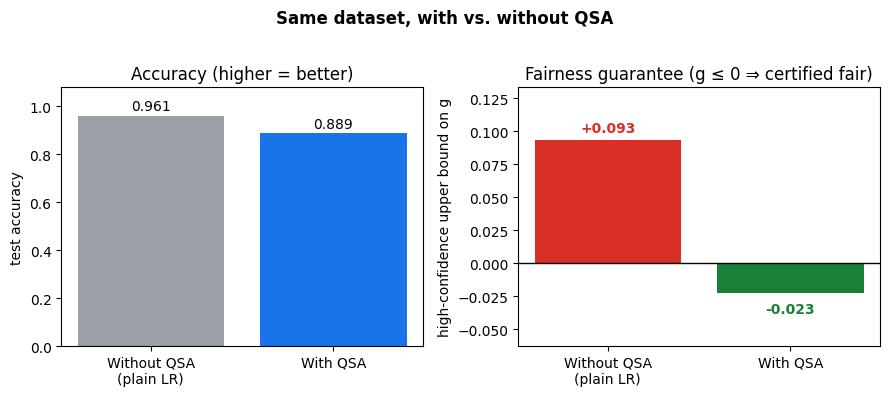

In [9]:
# Same dataset for both models. We seed NumPy so the noise feature columns
# (which get_data draws from the global RNG) are reproducible.
np.random.seed(0)
cmp_data = get_data(
    N=20000, features=5, t_ratio=0.5, tp0_ratio=0.4, tp1_ratio=0.6, random_seed=7
)
Xc_te, Yc_te, Tc_te, Xc_tr, Yc_tr, Tc_tr = data_split(
    frac=1.0, all_data=cmp_data, random_state=1, m_test=0.3
)
cmp_cfg = SeldonianConfig(delta=0.05, inequality=Inequality.T_TEST)


def accuracy(theta, theta1, X, Y):
    yhat = (predict(theta, theta1, X).detach().numpy() >= 0.5).astype(int)
    return float((yhat == Y).mean())


# Without QSA: plain logistic regression, no fairness constraint.
lr_theta, lr_theta1 = simple_logistic(Xc_tr, Yc_tr)
lr_acc = accuracy(lr_theta, lr_theta1, Xc_te, Yc_te)
lr_bound = float(eval_ghat(lr_theta, lr_theta1, Xc_te, Yc_te, Tc_te, "opt", cmp_cfg))

# With QSA: same data, fairness constraint enforced with high confidence.
qsa_theta, qsa_theta1, qsa_passed = QSA(Xc_tr, Yc_tr, Tc_tr, "opt", None, None, cmp_cfg)
qsa_acc = accuracy(qsa_theta, qsa_theta1, Xc_te, Yc_te)
qsa_bound = float(eval_ghat(qsa_theta, qsa_theta1, Xc_te, Yc_te, Tc_te, "opt", cmp_cfg))

for name, acc, bound in [
    ("Without QSA", lr_acc, lr_bound),
    ("With QSA   ", qsa_acc, qsa_bound),
]:
    verdict = "certified fair" if bound <= 0 else "NOT certifiable"
    print(f"{name}: accuracy={acc:.3f}  bound g={bound:+.3f}  → {verdict}")

labels = ["Without QSA\n(plain LR)", "With QSA"]
accs = [lr_acc, qsa_acc]
bounds = [lr_bound, qsa_bound]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

ax1.bar(labels, accs, color=["#9aa0a6", "#1a73e8"])
ax1.set_ylim(0, 1.08)
ax1.set_ylabel("test accuracy")
ax1.set_title("Accuracy (higher = better)")
for i, v in enumerate(accs):
    ax1.annotate(
        f"{v:.3f}", (i, v), textcoords="offset points", xytext=(0, 4), ha="center"
    )

bar_colors = ["#d93025" if b > 0 else "#188038" for b in bounds]
ax2.bar(labels, bounds, color=bar_colors)
ax2.axhline(0, color="black", linewidth=1)
pad = 0.04
ax2.set_ylim(min(bounds) - pad, max(bounds) + pad)
ax2.set_ylabel("high-confidence upper bound on g")
ax2.set_title("Fairness guarantee (g ≤ 0 ⇒ certified fair)")
for i, v in enumerate(bounds):
    ax2.annotate(
        f"{v:+.3f}",
        (i, v),
        textcoords="offset points",
        xytext=(0, 6 if v >= 0 else -14),
        ha="center",
        fontweight="bold",
        color=bar_colors[i],
    )

fig.suptitle("Same dataset, with vs. without QSA", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Next steps

- Swap in your own data: arrange features as `X`, binary labels as `Y`, and a binary sensitive attribute as `T` (all NumPy arrays), then call `QSA(X, Y, T, "opt", None, None, config)`.
- Write your own constraint in postfix form over `TP/FP/TN/FN(group)`.
- Read the docs: https://parulgupta1004.github.io/fair-seldonian/

Built on the Seldonian framework of Thomas et al., *Science* 366 (2019).